# Importing Necessary Libraries

In [21]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [22]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [23]:
data = pd.read_csv('D:/PhD research/qualificationExams/2026/selectedTopics2/anaconda/dataset/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv')

# Explore Data🔎 and Data Cleaning 🧹

In [26]:
data.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [27]:
data.shape

(940, 15)

In [28]:
data.Id.nunique()

33

In [31]:
cols =['Id','ActivityDate','TotalSteps','VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes','Calories']

df = data[cols]

In [32]:
df

,Id,ActivityDate,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,25,13,328,728,1985
1,1503960366,4/13/2016,10735,21,19,217,776,1797
2,1503960366,4/14/2016,10460,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,29,34,209,726,1745
4,1503960366,4/16/2016,12669,36,10,221,773,1863
...,...,...,...,...,...,...,...,...
935,8877689391,5/8/2016,10686,17,4,245,1174,2847
936,8877689391,5/9/2016,20226,73,19,217,1131,3710
937,8877689391,5/10/2016,10733,18,11,224,1187,2832
938,8877689391,5/11/2016,21420,88,12,213,1127,3832


In [33]:
df.rename(columns={'ActivityDate':'Data'},inplace=True)

In [34]:
df

,Id,Data,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,25,13,328,728,1985
1,1503960366,4/13/2016,10735,21,19,217,776,1797
2,1503960366,4/14/2016,10460,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,29,34,209,726,1745
4,1503960366,4/16/2016,12669,36,10,221,773,1863
...,...,...,...,...,...,...,...,...
935,8877689391,5/8/2016,10686,17,4,245,1174,2847
936,8877689391,5/9/2016,20226,73,19,217,1131,3710
937,8877689391,5/10/2016,10733,18,11,224,1187,2832
938,8877689391,5/11/2016,21420,88,12,213,1127,3832


In [35]:
df['TotalMinutes']=df.VeryActiveMinutes + df.FairlyActiveMinutes + df.LightlyActiveMinutes + df.SedentaryMinutes

In [36]:
df

,Id,Data,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes
0,1503960366,4/12/2016,13162,25,13,328,728,1985,1094
1,1503960366,4/13/2016,10735,21,19,217,776,1797,1033
2,1503960366,4/14/2016,10460,30,11,181,1218,1776,1440
3,1503960366,4/15/2016,9762,29,34,209,726,1745,998
4,1503960366,4/16/2016,12669,36,10,221,773,1863,1040
...,...,...,...,...,...,...,...,...,...
935,8877689391,5/8/2016,10686,17,4,245,1174,2847,1440
936,8877689391,5/9/2016,20226,73,19,217,1131,3710,1440
937,8877689391,5/10/2016,10733,18,11,224,1187,2832,1440
938,8877689391,5/11/2016,21420,88,12,213,1127,3832,1440


In [37]:
df['TotalHours']=round(df.TotalMinutes / 60)

In [38]:
df

,Id,Data,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,TotalHours
0,1503960366,4/12/2016,13162,25,13,328,728,1985,1094,18.0
1,1503960366,4/13/2016,10735,21,19,217,776,1797,1033,17.0
2,1503960366,4/14/2016,10460,30,11,181,1218,1776,1440,24.0
3,1503960366,4/15/2016,9762,29,34,209,726,1745,998,17.0
4,1503960366,4/16/2016,12669,36,10,221,773,1863,1040,17.0
...,...,...,...,...,...,...,...,...,...,...
935,8877689391,5/8/2016,10686,17,4,245,1174,2847,1440,24.0
936,8877689391,5/9/2016,20226,73,19,217,1131,3710,1440,24.0
937,8877689391,5/10/2016,10733,18,11,224,1187,2832,1440,24.0
938,8877689391,5/11/2016,21420,88,12,213,1127,3832,1440,24.0


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Id                    940 non-null    int64  
 1   Data                  940 non-null    str    
 2   TotalSteps            940 non-null    int64  
 3   VeryActiveMinutes     940 non-null    int64  
 4   FairlyActiveMinutes   940 non-null    int64  
 5   LightlyActiveMinutes  940 non-null    int64  
 6   SedentaryMinutes      940 non-null    int64  
 7   Calories              940 non-null    int64  
 8   TotalMinutes          940 non-null    int64  
 9   TotalHours            940 non-null    float64
dtypes: float64(1), int64(8), str(1)
memory usage: 73.6 KB


In [40]:
df.Data=pd.to_datetime(df.Data)
df.Data.dtypes

dtype('<M8[us]')

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Id                    940 non-null    int64         
 1   Data                  940 non-null    datetime64[us]
 2   TotalSteps            940 non-null    int64         
 3   VeryActiveMinutes     940 non-null    int64         
 4   FairlyActiveMinutes   940 non-null    int64         
 5   LightlyActiveMinutes  940 non-null    int64         
 6   SedentaryMinutes      940 non-null    int64         
 7   Calories              940 non-null    int64         
 8   TotalMinutes          940 non-null    int64         
 9   TotalHours            940 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(8)
memory usage: 73.6 KB


In [42]:
df['DayOfWeek'] = df.Data.dt.day_name()

In [43]:
df

,Id,Data,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,TotalHours,DayOfWeek
0,1503960366,2016-04-12,13162,25,13,328,728,1985,1094,18.0,Tuesday
1,1503960366,2016-04-13,10735,21,19,217,776,1797,1033,17.0,Wednesday
2,1503960366,2016-04-14,10460,30,11,181,1218,1776,1440,24.0,Thursday
3,1503960366,2016-04-15,9762,29,34,209,726,1745,998,17.0,Friday
4,1503960366,2016-04-16,12669,36,10,221,773,1863,1040,17.0,Saturday
...,...,...,...,...,...,...,...,...,...,...,...
935,8877689391,2016-05-08,10686,17,4,245,1174,2847,1440,24.0,Sunday
936,8877689391,2016-05-09,20226,73,19,217,1131,3710,1440,24.0,Monday
937,8877689391,2016-05-10,10733,18,11,224,1187,2832,1440,24.0,Tuesday
938,8877689391,2016-05-11,21420,88,12,213,1127,3832,1440,24.0,Wednesday


In [58]:
# Check missing values
print(df.isnull().sum())

Id                      0
Data                    0
TotalSteps              0
VeryActiveMinutes       0
FairlyActiveMinutes     0
LightlyActiveMinutes    0
SedentaryMinutes        0
Calories                0
TotalMinutes            0
TotalHours              0
DayOfWeek               0
dtype: int64


In [44]:
df.isna().sum()

Id                      0
Data                    0
TotalSteps              0
VeryActiveMinutes       0
FairlyActiveMinutes     0
LightlyActiveMinutes    0
SedentaryMinutes        0
Calories                0
TotalMinutes            0
TotalHours              0
DayOfWeek               0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(0)

# analyst data

In [46]:
df.describe()

,Id,Data,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,TotalHours
count,9.400000e+02,940,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,2016-04-26 06:53:37.021276,7637.910638,21.164894,13.564894,192.812766,991.210638,2303.609574,1218.753191,20.313830
min,1.503960e+09,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,2.320127e+09,2016-04-19 00:00:00,3789.750000,0.000000,0.000000,127.000000,729.750000,1828.500000,989.750000,16.000000
50%,4.445115e+09,2016-04-26 00:00:00,7405.500000,4.000000,6.000000,199.000000,1057.500000,2134.000000,1440.000000,24.000000
75%,6.962181e+09,2016-05-04 00:00:00,10727.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000,1440.000000,24.000000
max,8.877689e+09,2016-05-12 00:00:00,36019.000000,210.000000,143.000000,518.000000,1440.000000,4900.000000,1440.000000,24.000000
std,2.424805e+09,NaN,5087.150742,32.844803,19.987404,109.174700,301.267437,718.166862,265.931767,4.437283


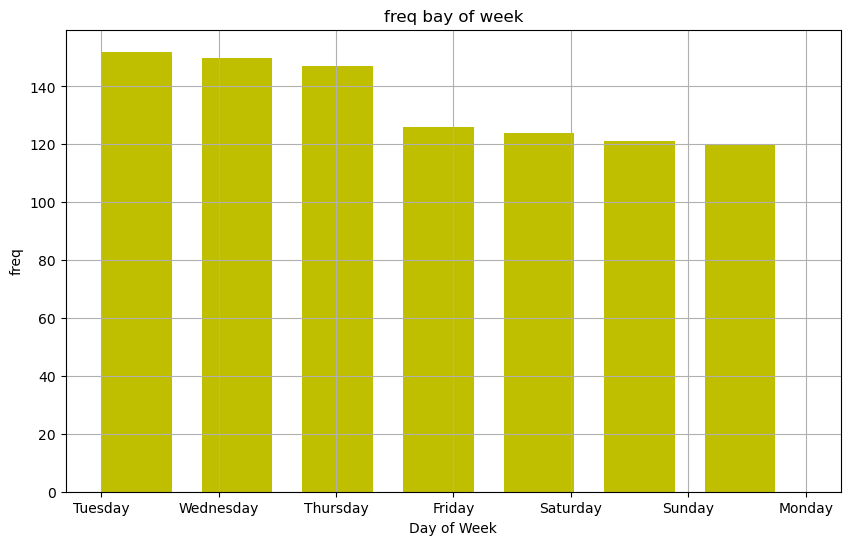

In [47]:
plt.figure(figsize=((10,6)))
plt.hist(df.DayOfWeek,color='y',bins=7,width =.6,align='mid')

plt.xlabel('Day of Week')
plt.ylabel('freq')
plt.title('freq bay of week')

plt.grid()
plt.show()

In [48]:
mask = df.drop(['DayOfWeek','Data'],axis=1)

In [49]:
mask.corr()

,Id,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalMinutes,TotalHours
Id,1.000000,0.185721,0.303608,0.051158,-0.098754,-0.043319,0.396671,-0.048274,-0.048140
TotalSteps,0.185721,1.000000,0.667079,0.498693,0.569600,-0.327484,0.591568,-0.017285,-0.018152
VeryActiveMinutes,0.303608,0.667079,1.000000,0.312420,0.051926,-0.164671,0.615838,-0.018244,-0.021064
FairlyActiveMinutes,0.051158,0.498693,0.312420,1.000000,0.148820,-0.237446,0.297623,-0.094155,-0.094941
LightlyActiveMinutes,-0.098754,0.569600,0.051926,0.148820,1.000000,-0.437104,0.286718,-0.067049,-0.066640
SedentaryMinutes,-0.043319,-0.327484,-0.164671,-0.237446,-0.437104,1.000000,-0.106973,0.915243,0.914539
Calories,0.396671,0.591568,0.615838,0.297623,0.286718,-0.106973,1.000000,0.094951,0.093314
TotalMinutes,-0.048274,-0.017285,-0.018244,-0.094155,-0.067049,0.915243,0.094951,1.000000,0.998963
TotalHours,-0.048140,-0.018152,-0.021064,-0.094941,-0.066640,0.914539,0.093314,0.998963,1.000000


<Axes: >

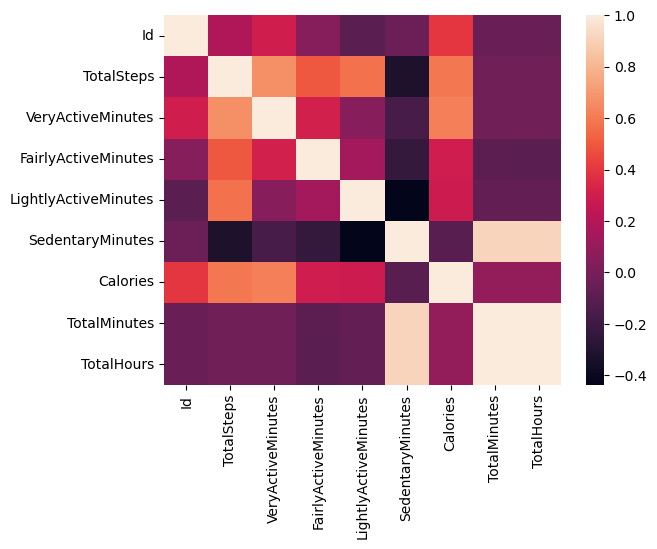

In [50]:
sns.heatmap(mask.corr())

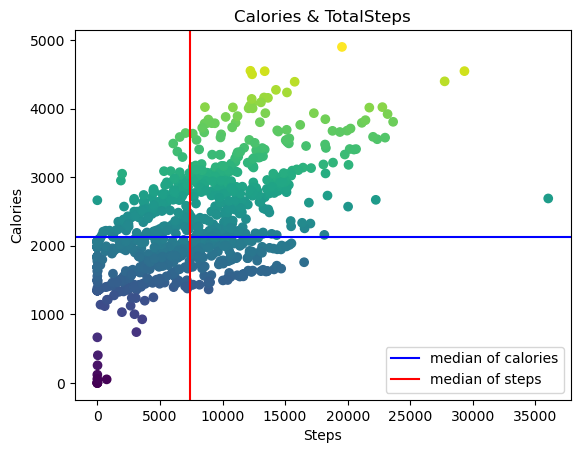

In [51]:
plt.scatter(mask.TotalSteps,mask.Calories,c=mask.Calories )

median_steps = 7405
median_calories = 2134

plt.axhline(median_calories,color = 'b',label = 'median of calories')
plt.axvline(median_steps,color = 'r',label = 'median of steps')

plt.xlabel('Steps')
plt.ylabel('Calories')
plt.title('Calories & TotalSteps')

plt.legend()
plt.show()

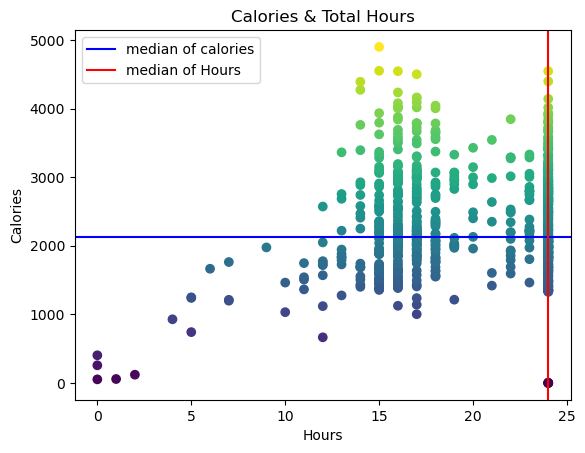

In [52]:
plt.scatter(mask.TotalHours,mask.Calories,c=mask.Calories )

median_Hours = 24
median_calories = 2134

plt.axhline(median_calories,color = 'b',label = 'median of calories')
plt.axvline(median_Hours,color = 'r',label = 'median of Hours')

plt.xlabel('Hours')
plt.ylabel('Calories')
plt.title('Calories & Total Hours')

plt.legend()
plt.show()

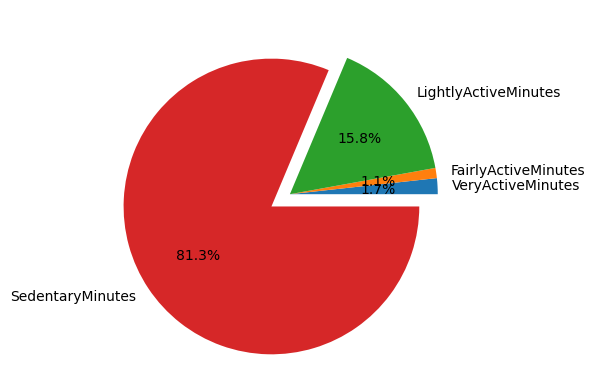

In [53]:
minutes = [df.VeryActiveMinutes.sum(),df.FairlyActiveMinutes.sum(),
           df.LightlyActiveMinutes.sum(),df.SedentaryMinutes.sum()
          ]
labels = ['VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes','SedentaryMinutes']

plt.pie(minutes,labels=labels,autopct='%1.1f%%',explode=[0,0,0,0.15])

plt.show()

#  Let's Create activity level classification

In [68]:
def classify_activity(steps):
    if steps < 5000:
        return "Sedentary"
    elif steps < 10000:
        return "Moderate"
    else:
        return "Active"

df['ActivityLevel'] = df['TotalSteps'].apply(classify_activity)

# Sleep efficiency proxy (example)
df['CaloriesPerStep'] = df['Calories'] / (df['TotalSteps'] + 1)

In [69]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['ActivityLevelEncoded'] = le.fit_transform(df['ActivityLevel'])

In [70]:
X = df[['TotalSteps', 'Calories', 'VeryActiveMinutes', 'SedentaryMinutes']]
y = df['ActivityLevelEncoded']

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [72]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [73]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00        79
           2       1.00      1.00      1.00        60

    accuracy                           1.00       188
   macro avg       1.00      1.00      1.00       188
weighted avg       1.00      1.00      1.00       188



In [74]:
# Example new user
new_data = [[8000, 2200, 30, 600]]

prediction = model.predict(new_data)
print("Predicted Activity Level:", le.inverse_transform(prediction))

Predicted Activity Level: ['Moderate']


# Add Recommendation System (IMPORTANT 🔥)

In [85]:
def recommend(activity_level):
    if activity_level == "Sedentary":
        return "Increase daily steps and reduce sedentary time."
    elif activity_level == "Moderate":
        return "Maintain activity and add light exercise."
    else:
        return "Great job! Maintain your healthy lifestyle."

user_level = le.inverse_transform(prediction)[0]
print(recommend(user_level))

Maintain activity and add light exercise.


# 🧠 PART 1 — Deep Learning (LSTM for Time-Series)
## ✅ Why LSTM?

### Lifestyle data = time-series (daily steps, calories over time)
### LSTM captures temporal patterns → much stronger than Random Forest

In [86]:
# Convert date
df['ActivityDate'] = pd.to_datetime(df['Data'])

# Sort by user & time
df = df.sort_values(by=['Id', 'ActivityDate'])

# Step 3: Create Sequences (VERY IMPORTANT 🔥)
## We convert data into sequences of 7 days → predict next day lifestyle

In [93]:
sequence_length = 7

features = ['TotalSteps', 'Calories', 'VeryActiveMinutes', 'SedentaryMinutes']

data = df[features].values

X, y = [], []

for i in range(len(data) - sequence_length):
    X.append(data[i:i+sequence_length])
    y.append(data[i+sequence_length][0])  # predict steps

X = np.array(X)
y = np.array(y)

print(X.shape)  # (samples, time_steps, features)

(933, 7, 4)


# Step 4: Normalize Data

In [94]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y = scaler.fit_transform(y.reshape(-1,1))

In [95]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))  # Predict steps

model.compile(optimizer='adam', loss='mse')
print("Model compiled. Now showing summary:")
model.summary()

Model compiled. Now showing summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 7, 64)               │          17,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
history = model.fit(
    X, y,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0201 - val_loss: 0.0231
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0144 - val_loss: 0.0220
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0131 - val_loss: 0.0230
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0125 - val_loss: 0.0208
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0126 - val_loss: 0.0204
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0121 - val_loss: 0.0211
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0124 - val_loss: 0.0204
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0124 - val_loss: 0.0207
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0123 - val_loss: 0.0207
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0122 - val_loss: 0.0214
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0121 - val_loss: 0.0214
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

In [97]:
pred = model.predict(X[-1].reshape(1, sequence_length, len(features)))

predicted_steps = scaler.inverse_transform(pred)
print("Predicted Steps:", predicted_steps)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
Predicted Steps: [[12481.038]]


# 📊 PART 2 — Visualization Dashboard

# Using Python (Matplotlib + Seaborn)

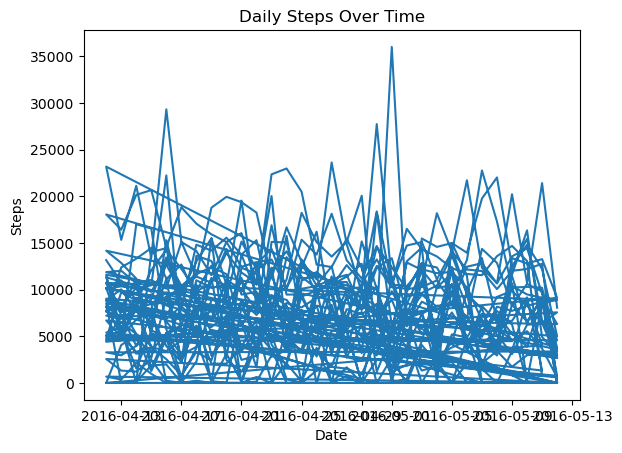

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Steps over time
plt.figure()
plt.plot(df['ActivityDate'], df['TotalSteps'])
plt.title("Daily Steps Over Time")
plt.xlabel("Date")
plt.ylabel("Steps")
plt.show()

# Correlation Heatmap

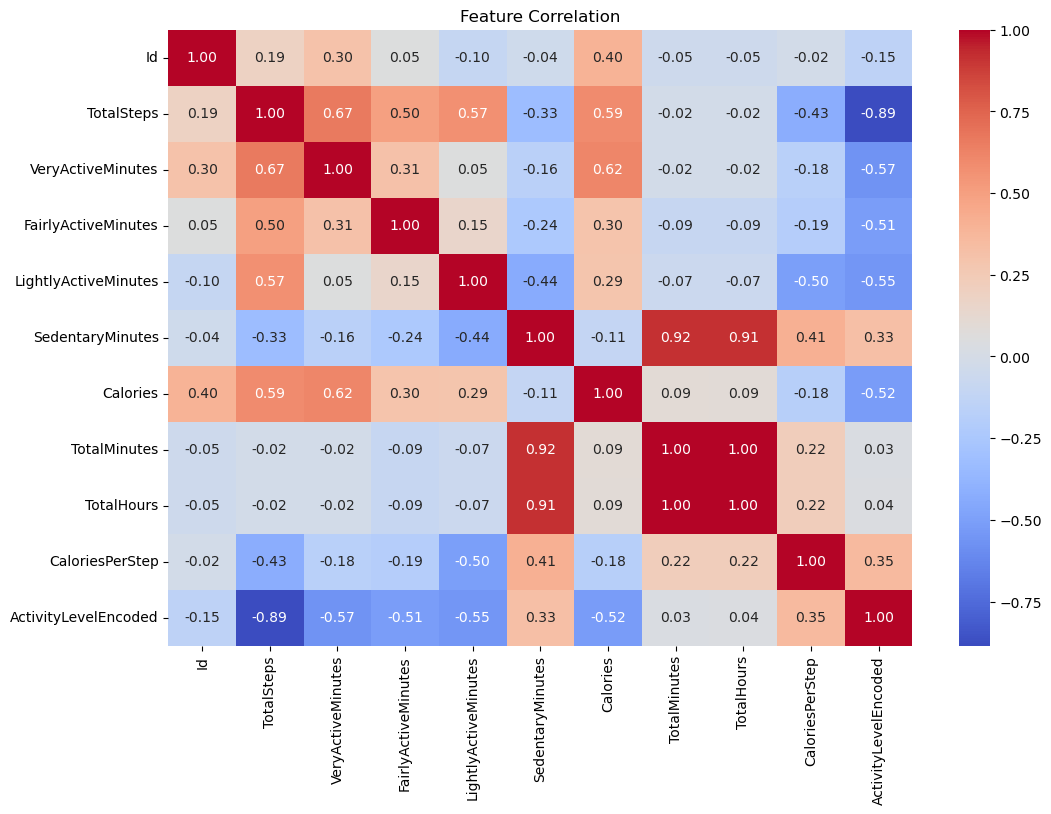

In [100]:
plt.figure(figsize=(12, 8)) # Added size to make it readable
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation")
plt.show()

# Activity Distribution

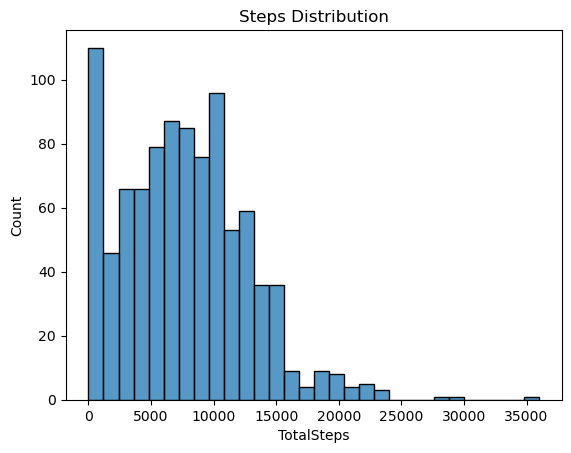

In [101]:
plt.figure()
sns.histplot(df['TotalSteps'], bins=30)
plt.title("Steps Distribution")
plt.show()